In [7]:
# ============================================================
# BLOCK 1: Imports and global configuration
# ============================================================
import os
import time
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Tuple, Optional
from scipy.spatial import cKDTree

# --- Global evaluation settings (kept in one place for reproducibility) ---
EPS_PX          = 3.0        # localization tolerance for repeatability (HPatches protocol)
HPATCHES_ROOT   = "hpatches-mini" # <- change to your local path
RESULTS_DIR     = Path("results")
RANDOM_SEED     = 0
np.random.seed(RANDOM_SEED)

print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

OpenCV: 4.13.0
NumPy : 2.5.3


In [8]:
# ============================================================
# BLOCK 2: HPatches-style dataset loading
# ============================================================
# Expected layout:
#   hpatches/
#     i_ajuntament/   1.ppm  2.ppm  ...  H_1_2  H_1_3 ...
#     v_artisans/     1.ppm  2.ppm  ...  H_1_2  H_1_3 ...
#
# `kind` is inferred from the first character of the sequence name:
#   'i' -> illumination changes
#   'v' -> viewpoint changes
# ============================================================

@dataclass
class Sequence:
    name: str
    kind: str                                        # 'i' or 'v'
    ref_path: Path
    targets: List[Path] = field(default_factory=list)
    homographies: List[np.ndarray] = field(default_factory=list)  # ref -> target


def load_hpatches(root: str,
                  max_sequences: Optional[int] = None,
                  kinds: Tuple[str, ...] = ("i", "v")) -> List[Sequence]:
    """Load HPatches sequences. Returns a list of Sequence objects."""
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"HPatches root not found: {root.resolve()}")

    seqs: List[Sequence] = []
    for seq_dir in sorted(root.iterdir()):
        if not seq_dir.is_dir():
            continue
        kind = seq_dir.name[0]
        if kind not in kinds:
            continue

        imgs = sorted(p for p in seq_dir.iterdir()
                      if p.suffix.lower() in (".ppm", ".png", ".jpg"))
        if len(imgs) < 2:
            continue

        ref = imgs[0]
        targets, Hs = [], []
        for i, tgt in enumerate(imgs[1:], start=2):
            H_path = seq_dir / f"H_1_{i}"
            if not H_path.exists():
                continue
            H = np.loadtxt(H_path).astype(np.float64)
            # sanity check: shape must be 3x3
            if H.shape != (3, 3):
                continue
            targets.append(tgt)
            Hs.append(H)

        if targets:
            seqs.append(Sequence(seq_dir.name, kind, ref, targets, Hs))

        if max_sequences and len(seqs) >= max_sequences:
            break

    return seqs


def make_synthetic_sequences(out_root: str = "synthetic_hpatches") -> str:
    """
    Fallback used when HPatches is not available.
    Creates a small textured image and a homography-warped copy,
    stored in HPatches-compatible layout.
    """
    rng = np.random.default_rng(RANDOM_SEED)

    base = rng.integers(0, 255, size=(480, 640), dtype=np.uint8)
    base = cv2.GaussianBlur(base, (5, 5), 1.0)
    cv2.putText(base, "SYNTHETIC", (40, 240),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, 255, 3)
    for _ in range(60):
        x, y = int(rng.integers(0, 640)), int(rng.integers(0, 480))
        cv2.circle(base, (x, y), int(rng.integers(3, 15)),
                   int(rng.integers(0, 255)), -1)

    H = np.array([[1.05, 0.02, -10.0],
                  [-0.01, 1.03,  5.0],
                  [1e-4, 1e-4,   1.0]])
    warped = cv2.warpPerspective(base, H, (640, 480))

    tmp = Path(out_root) / "i_synth"
    tmp.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(tmp / "1.png"), base)
    cv2.imwrite(str(tmp / "2.png"), warped)
    np.savetxt(tmp / "H_1_2", H)
    return out_root


def get_dataset() -> List[Sequence]:
    """Convenience loader: falls back to synthetic data if HPatches is missing."""
    if Path(HPATCHES_ROOT).exists():
        print(f"[INFO] Loading HPatches from {HPATCHES_ROOT}")
        seqs = load_hpatches(HPATCHES_ROOT)
    else:
        print(f"[WARN] {HPATCHES_ROOT} not found -> using synthetic data")
        root = make_synthetic_sequences()
        seqs = load_hpatches(root)

    n_pairs = sum(len(s.targets) for s in seqs)
    n_i = sum(1 for s in seqs if s.kind == "i")
    n_v = sum(1 for s in seqs if s.kind == "v")
    print(f"[INFO] Loaded {len(seqs)} sequences "
          f"({n_i} illumination, {n_v} viewpoint), {n_pairs} image pairs")
    return seqs

In [9]:
# ============================================================
# BLOCK 3: Detector wrappers
# ============================================================
# Every detector is a factory returning a callable:
#     fn(img_gray_uint8) -> (kp_xy: (N,2) float32, runtime_seconds: float)
#
# Keeping the interface uniform lets the benchmark loop treat all
# detectors identically. Detectors are constructed via make_*() so
# hyperparameters can be swept without rewriting the eval code.
# ============================================================

KeypointFn = Callable[[np.ndarray], Tuple[np.ndarray, float]]


# Add a global cap
MAX_KP_PER_IMAGE = 2000

def _to_xy(kps, max_kp=MAX_KP_PER_IMAGE):
    if len(kps) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    # OpenCV returns keypoints in detection order; keep the strongest first
    # if you want a principled truncation, sort by response:
    if len(kps) > max_kp:
        kps = sorted(kps, key=lambda k: k.response, reverse=True)[:max_kp]
    return np.array([kp.pt for kp in kps], dtype=np.float32)


# ---------- SIFT ----------
def make_sift(nfeatures: int = 0,
              contrastThreshold: float = 0.04,
              edgeThreshold: float = 10.0,
              sigma: float = 1.6) -> KeypointFn:
    det = cv2.SIFT_create(nfeatures=nfeatures,
                          contrastThreshold=contrastThreshold,
                          edgeThreshold=edgeThreshold,
                          sigma=sigma)

    def fn(img: np.ndarray):
        t0 = time.perf_counter()
        kps = det.detect(img, None)
        dt = time.perf_counter() - t0
        return _to_xy(kps), dt
    return fn


# ---------- FAST ----------
def make_fast(threshold: int = 20,
              nonmaxSuppression: bool = True,
              type: int = cv2.FAST_FEATURE_DETECTOR_TYPE_9_16) -> KeypointFn:
    det = cv2.FastFeatureDetector_create(
        threshold=threshold,
        nonmaxSuppression=nonmaxSuppression,
        type=type)

    def fn(img: np.ndarray):
        t0 = time.perf_counter()
        kps = det.detect(img, None)
        dt = time.perf_counter() - t0
        return _to_xy(kps), dt
    return fn


# ---------- ORB (detector only, no descriptor) ----------
def make_orb_detector(nfeatures: int = 500,
                      scaleFactor: float = 1.2,
                      nlevels: int = 8,
                      edgeThreshold: int = 31,
                      fastThreshold: int = 20) -> KeypointFn:
    det = cv2.ORB_create(nfeatures=nfeatures,
                         scaleFactor=scaleFactor,
                         nlevels=nlevels,
                         edgeThreshold=edgeThreshold,
                         fastThreshold=fastThreshold)

    def fn(img: np.ndarray):
        t0 = time.perf_counter()
        kps = det.detect(img, None)
        dt = time.perf_counter() - t0
        return _to_xy(kps), dt
    return fn


# ---------- KAZE ----------
def make_kaze(threshold: float = 0.001,
              nOctaves: int = 4,
              nOctaveLayers: int = 4,
              diffusivity: int = cv2.KAZE_DIFF_PM_G2) -> KeypointFn:
    det = cv2.KAZE_create(threshold=threshold,
                          nOctaves=nOctaves,
                          nOctaveLayers=nOctaveLayers,
                          diffusivity=diffusivity)

    def fn(img: np.ndarray):
        t0 = time.perf_counter()
        kps = det.detect(img, None)
        dt = time.perf_counter() - t0
        return _to_xy(kps), dt
    return fn


# ---------- SuperPoint (optional; requires lightglue + torch) ----------
# Uncomment after `pip install lightglue torch`.
#
# from lightglue import SuperPoint
# import torch
#
# def make_superpoint(max_num_keypoints: int = 1024,
#                     detection_threshold: float = 0.015,
#                     nms_radius: int = 4) -> KeypointFn:
#     model = SuperPoint(
#         max_num_keypoints=max_num_keypoints,
#         detection_threshold=detection_threshold,
#         nms_radius=nms_radius,
#     ).eval()
#
#     def fn(img: np.ndarray):
#         t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0) / 255.0
#         t0 = time.perf_counter()
#         with torch.no_grad():
#             out = model.extract(t)
#         dt = time.perf_counter() - t0
#         kps = out["keypoints"][0].cpu().numpy().astype(np.float32)
#         return kps, dt
#     return fn


# Registry used by the benchmark to iterate over detectors
DETECTOR_FACTORIES = {
    "SIFT": make_sift,
    "FAST": make_fast,
    "ORB" : make_orb_detector,
    "KAZE": make_kaze,
    # "SuperPoint": make_superpoint,
}

DEFAULT_CONFIG = {
    "SIFT": dict(nfeatures=0, contrastThreshold=0.04),
    "FAST": dict(threshold=20, nonmaxSuppression=True),
    "ORB" : dict(nfeatures=500, fastThreshold=20),
    "KAZE": dict(threshold=0.001),
    # "SuperPoint": dict(max_num_keypoints=1024, detection_threshold=0.015),
}

In [10]:
# ============================================================
# BLOCK 4: Benchmark pipeline
# ============================================================
# Contains:
#   - repeatability()         : pairwise metric
#   - evaluate_detector()     : run a detector across all sequences
#   - summarize()             : aggregate by transformation kind
#   - sweep()                 : 1-D hyperparameter sweep
# ============================================================

def warp_points(pts_xy: np.ndarray, H: np.ndarray) -> np.ndarray:
    """Apply homography H to (N,2) points."""
    if len(pts_xy) == 0:
        return pts_xy
    ones = np.ones((len(pts_xy), 1), dtype=np.float64)
    P = np.hstack([pts_xy.astype(np.float64), ones])   # N x 3
    Q = (H @ P.T).T                                    # N x 3
    Q = Q[:, :2] / Q[:, 2:3]
    return Q.astype(np.float32)


def repeatability(kp1: np.ndarray,
                  kp2: np.ndarray,
                  H: np.ndarray,
                  img2_shape: Tuple[int, int],
                  eps: float = EPS_PX) -> Dict[str, float]:
    """
    Standard detector repeatability under homography H (ref -> tgt).

    Protocol:
      1. Warp kp1 into the target frame.
      2. Discard warped points outside the target image.
      3. A warped reference keypoint is *repeatable* if a target keypoint
         exists within `eps` pixels.
      4. Repeatability = n_repeatable / n_valid.

    Returns a dict with the raw counts so the metric can be reproduced.
    """
    n1, n2 = len(kp1), len(kp2)
    base = {"n1": n1, "n2": n2, "n1_valid": 0,
            "n_repeatable": 0, "repeatability": 0.0}
    if n1 == 0 or n2 == 0:
        return base

    h, w = img2_shape
    kp1_w = warp_points(kp1, H)

    inside = ((kp1_w[:, 0] >= 0) & (kp1_w[:, 0] < w) &
              (kp1_w[:, 1] >= 0) & (kp1_w[:, 1] < h))
    kp1_valid = kp1_w[inside]
    n_valid = len(kp1_valid)
    if n_valid == 0:
        return base

    tree = cKDTree(kp2)
    d, _ = tree.query(kp1_valid, k=1)
    n_rep = int(np.sum(d <= eps))

    return {
        "n1": n1, "n2": n2,
        "n1_valid": n_valid,
        "n_repeatable": n_rep,
        "repeatability": n_rep / n_valid,
    }


@dataclass
class EvalResult:
    detector: str
    config: dict
    sequence: str
    kind: str
    n_ref: int
    n_tgt: int
    n_ref_valid: int
    n_repeatable: int
    repeatability: float
    runtime_ref: float
    runtime_tgt: float


def evaluate_detector(detector_name: str,
                      detector_fn: KeypointFn,
                      sequences: List[Sequence],
                      config: Optional[dict] = None,
                      eps: float = EPS_PX) -> List[EvalResult]:
    """Run a single detector across all sequence/pair combinations."""
    config = config or {}
    results: List[EvalResult] = []

    for seq in sequences:
        img1 = cv2.imread(str(seq.ref_path), cv2.IMREAD_GRAYSCALE)
        if img1 is None:
            continue
        kp1, t1 = detector_fn(img1)

        for tgt_path, H in zip(seq.targets, seq.homographies):
            img2 = cv2.imread(str(tgt_path), cv2.IMREAD_GRAYSCALE)
            if img2 is None:
                continue
            kp2, t2 = detector_fn(img2)

            rep = repeatability(kp1, kp2, H, img2.shape, eps=eps)

            results.append(EvalResult(
                detector=detector_name,
                config=dict(config),
                sequence=seq.name,
                kind=seq.kind,
                n_ref=rep["n1"],
                n_tgt=rep["n2"],
                n_ref_valid=rep["n1_valid"],
                n_repeatable=rep["n_repeatable"],
                repeatability=rep["repeatability"],
                runtime_ref=t1,
                runtime_tgt=t2,
            ))
    return results


def summarize(results: List[EvalResult]) -> Dict[str, float]:
    """Aggregate results, broken down by transformation kind."""
    out: Dict[str, float] = {}
    for kind in ("i", "v", "all"):
        sel = results if kind == "all" else [r for r in results if r.kind == kind]
        if not sel:
            continue
        n_valid = sum(r.n_ref_valid  for r in sel)
        n_rep   = sum(r.n_repeatable for r in sel)
        out[f"repeatability_{kind}"]  = (n_rep / n_valid) if n_valid else 0.0
        out[f"n_ref_{kind}"]          = int(np.mean([r.n_ref for r in sel]))
        out[f"n_tgt_{kind}"]          = int(np.mean([r.n_tgt for r in sel]))
        out[f"runtime_ref_{kind}"]    = float(np.mean([r.runtime_ref for r in sel]))
        out[f"runtime_tgt_{kind}"]    = float(np.mean([r.runtime_tgt for r in sel]))
    return out


def sweep(detector_name: str,
          factory: Callable[..., KeypointFn],
          param_name: str,
          values: List,
          sequences: List[Sequence],
          fixed: Optional[dict] = None,
          eps: float = EPS_PX) -> "pd.DataFrame":
    """Sweep one hyperparameter of a detector factory; return a summary table."""
    import pandas as pd
    fixed = fixed or {}
    rows = []
    for v in values:
        kwargs = dict(fixed)
        kwargs[param_name] = v
        fn = factory(**kwargs)
        res = evaluate_detector(
            detector_name, fn, sequences,
            config={param_name: v, **fixed},
            eps=eps,
        )
        s = summarize(res)
        rows.append({
            "detector": detector_name,
            "param": param_name,
            "value": v,
            "n_kp_ref": s.get("n_ref_all", 0),
            "repeatability_i": s.get("repeatability_i", 0.0),
            "repeatability_v": s.get("repeatability_v", 0.0),
            "repeatability_all": s.get("repeatability_all", 0.0),
            "runtime_ms_ref": 1000 * s.get("runtime_ref_all", 0.0),
        })
    return pd.DataFrame(rows)

In [11]:
# ============================================================
# BLOCK 5: Run baseline benchmark
# ============================================================
import pandas as pd
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

sequences = get_dataset()

baseline_rows = []
for name, factory in DETECTOR_FACTORIES.items():
    cfg = DEFAULT_CONFIG.get(name, {})
    print(f"[RUN] {name} baseline: {cfg}")
    fn = factory(**cfg)
    res = evaluate_detector(name, fn, sequences, config=cfg)
    baseline_rows.append({"detector": name, "config": cfg, **summarize(res)})

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

[INFO] Loading HPatches from hpatches-mini
[INFO] Loaded 11 sequences (5 illumination, 6 viewpoint), 55 image pairs
[RUN] SIFT baseline: {'nfeatures': 0, 'contrastThreshold': 0.04}
[RUN] FAST baseline: {'threshold': 20, 'nonmaxSuppression': True}
[RUN] ORB baseline: {'nfeatures': 500, 'fastThreshold': 20}
[RUN] KAZE baseline: {'threshold': 0.001}


,detector,config,repeatability_i,n_ref_i,n_tgt_i,runtime_ref_i,runtime_tgt_i,repeatability_v,n_ref_v,n_tgt_v,runtime_ref_v,runtime_tgt_v,repeatability_all,n_ref_all,n_tgt_all,runtime_ref_all,runtime_tgt_all
0,SIFT,"{'nfeatures': 0, 'contrastThreshold': 0.04}",0.3980,1589,1460,0.1282,0.1269,0.4347,1720,1869,0.1305,0.1258,0.4180,1660,1683,0.1294,0.1263
1,FAST,"{'threshold': 20, 'nonmaxSuppression': True}",0.5280,1596,1569,0.0012,0.0012,0.5121,1828,1797,0.0032,0.0038,0.5191,1723,1694,0.0023,0.0026
2,ORB,"{'nfeatures': 500, 'fastThreshold': 20}",0.4555,500,500,0.0199,0.0185,0.5043,500,500,0.0270,0.0224,0.4818,500,500,0.0238,0.0206
3,KAZE,{'threshold': 0.001},0.5186,1272,1278,0.7755,0.8104,0.5486,1293,1510,0.7716,0.6827,0.5346,1283,1404,0.7734,0.7407


In [12]:
# ============================================================
# BLOCK 6: Hyperparameter sweeps
# ============================================================
# For each detector we sweep the parameter that most affects the
# trade-off between density and repeatability. Any other parameter
# can be swept by changing `param_name` and `values`.

sweeps: Dict[str, pd.DataFrame] = {}

sweeps["SIFT"] = sweep(
    "SIFT", make_sift, "contrastThreshold",
    values=[0.01, 0.02, 0.04, 0.08, 0.15],
    sequences=sequences,
)

sweeps["FAST"] = sweep(
    "FAST", make_fast, "threshold",
    values=[5, 10, 20, 40, 80],
    sequences=sequences,
)

sweeps["ORB"] = sweep(
    "ORB", make_orb_detector, "fastThreshold",
    values=[5, 10, 20, 40, 80],
    sequences=sequences,
    fixed={"nfeatures": 2000},
)

sweeps["KAZE"] = sweep(
    "KAZE", make_kaze, "threshold",
    values=[0.0001, 0.0005, 0.001, 0.005, 0.01],
    sequences=sequences,
)

for name, df in sweeps.items():
    print(f"\n=== {name} sweep ===")
    display(df)


=== SIFT sweep ===


,detector,param,value,n_kp_ref,repeatability_i,repeatability_v,repeatability_all,runtime_ms_ref
0,SIFT,contrastThreshold,0.0100,2000,0.4124,0.4072,0.4096,228.6408
1,SIFT,contrastThreshold,0.0200,1977,0.3992,0.4072,0.4035,298.3791
2,SIFT,contrastThreshold,0.0400,1660,0.3980,0.4347,0.4180,288.5690
3,SIFT,contrastThreshold,0.0800,967,0.3658,0.4583,0.4181,283.9553
4,SIFT,contrastThreshold,0.1500,163,0.3349,0.3969,0.3625,286.2164



=== FAST sweep ===


,detector,param,value,n_kp_ref,repeatability_i,repeatability_v,repeatability_all,runtime_ms_ref
0,FAST,threshold,5,2000,0.5285,0.4994,0.5131,8.1262
1,FAST,threshold,10,2000,0.5266,0.4994,0.5122,4.5187
2,FAST,threshold,20,1723,0.5280,0.5121,0.5191,1.8943
3,FAST,threshold,40,895,0.4914,0.5356,0.5149,0.7854
4,FAST,threshold,80,162,0.4307,0.3709,0.4052,0.3264



=== ORB sweep ===


,detector,param,value,n_kp_ref,repeatability_i,repeatability_v,repeatability_all,runtime_ms_ref
0,ORB,fastThreshold,5,2000,0.5730,0.5953,0.5850,29.0899
1,ORB,fastThreshold,10,2000,0.5794,0.5952,0.5879,23.1590
2,ORB,fastThreshold,20,1921,0.5559,0.6186,0.5886,11.4792
3,ORB,fastThreshold,40,1344,0.5557,0.6674,0.6114,6.6700
4,ORB,fastThreshold,80,429,0.4791,0.6173,0.5420,4.8074



=== KAZE sweep ===


,detector,param,value,n_kp_ref,repeatability_i,repeatability_v,repeatability_all,runtime_ms_ref
0,KAZE,threshold,0.0001,2000,0.5113,0.5020,0.5063,968.8362
1,KAZE,threshold,0.0005,1643,0.5115,0.5238,0.5182,841.1709
2,KAZE,threshold,0.0010,1283,0.5186,0.5486,0.5346,776.3700
3,KAZE,threshold,0.0050,244,0.4807,0.5012,0.4913,719.9213
4,KAZE,threshold,0.0100,75,0.4214,0.4033,0.4139,518.2614


In [ ]:
# ============================================================
# BLOCK 7: Plots
# ============================================================
# Repeatability vs. #keypoints is the most informative view: it shows
# whether a detector is *efficient*, not just *dense*.
# ============================================================

def plot_sweep(df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(df["n_kp_ref"], df["repeatability_i"], "o-", label="illumination")
    axes[0].plot(df["n_kp_ref"], df["repeatability_v"], "s-", label="viewpoint")
    axes[0].set_xlabel("#keypoints (ref, mean)")
    axes[0].set_ylabel("repeatability")
    axes[0].set_title(f"{title}: repeatability vs. #keypoints")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(df["n_kp_ref"], df["runtime_ms_ref"], "o-", color="tab:red")
    axes[1].set_xlabel("#keypoints (ref, mean)")
    axes[1].set_ylabel("runtime (ms, ref)")
    axes[1].set_title(f"{title}: runtime vs. #keypoints")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


for name, df in sweeps.items():
    plot_sweep(df, f"{name} sweep")

In [13]:
# ============================================================
# BLOCK 8: Compare detectors at matched #keypoints
# ============================================================
# Comparing detectors at their default settings is unfair because
# each produces a very different number of keypoints. Pick, for
# each detector, the configuration closest to a common target.
# ============================================================

TARGET_N = 1000   # aim for ~1000 keypoints per image

def closest_to(df: pd.DataFrame, target_n: int) -> pd.Series:
    idx = (df["n_kp_ref"] - target_n).abs().idxmin()
    return df.loc[idx]

matched = pd.DataFrame([
    closest_to(sweeps["SIFT"], TARGET_N),
    closest_to(sweeps["FAST"], TARGET_N),
    closest_to(sweeps["ORB"],  TARGET_N),
    closest_to(sweeps["KAZE"], TARGET_N),
]).reset_index(drop=True)

display(matched)

,detector,param,value,n_kp_ref,repeatability_i,repeatability_v,repeatability_all,runtime_ms_ref
0,SIFT,contrastThreshold,0.0800,967,0.3658,0.4583,0.4181,283.9553
1,FAST,threshold,40.0000,895,0.4914,0.5356,0.5149,0.7854
2,ORB,fastThreshold,40.0000,1344,0.5557,0.6674,0.6114,6.6700
3,KAZE,threshold,0.0010,1283,0.5186,0.5486,0.5346,776.3700


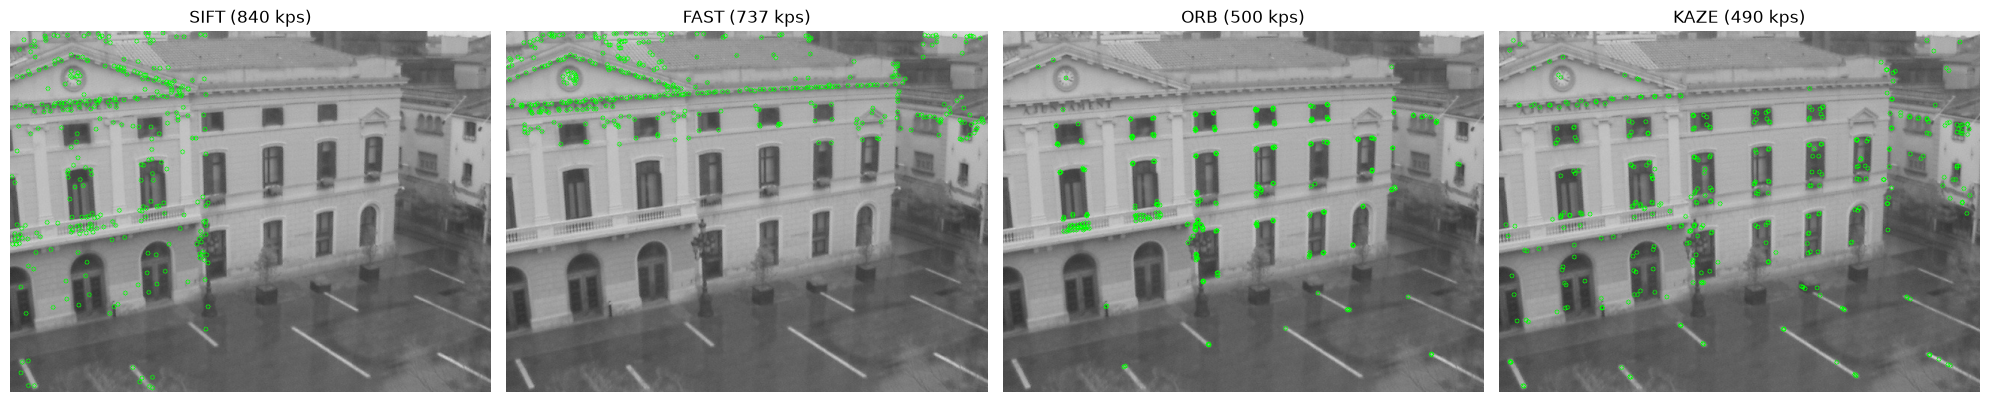

In [14]:
# ============================================================
# BLOCK 9: Qualitative visualization of detections
# ============================================================

def visualize_detections(img_path: str,
                         detectors: Dict[str, KeypointFn],
                         max_draw: int = 400):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    n = len(detectors)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (name, fn) in zip(axes, detectors.items()):
        kps, _ = fn(img)
        vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        for x, y in kps[:max_draw]:
            cv2.circle(vis, (int(round(x)), int(round(y))), 3, (0, 255, 0), 1)
        ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{name} ({len(kps)} kps)")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Use the reference image from the first sequence
ref_img_path = str(sequences[0].ref_path)

visualize_detections(ref_img_path, {
    name: factory(**DEFAULT_CONFIG.get(name, {}))
    for name, factory in DETECTOR_FACTORIES.items()
})

In [15]:
# ============================================================
# BLOCK 10: Persist results for the report
# ============================================================

RESULTS_DIR.mkdir(exist_ok=True)

baseline_df.to_csv(RESULTS_DIR / "detector_baseline.csv", index=False)
for name, df in sweeps.items():
    df.to_csv(RESULTS_DIR / f"sweep_{name.lower()}.csv", index=False)
matched.to_csv(RESULTS_DIR / "matched_density_comparison.csv", index=False)

# Save the exact configuration used (reproducibility requirement)
meta = {
    "opencv_version": cv2.__version__,
    "numpy_version": np.__version__,
    "eps_px": EPS_PX,
    "hpatches_root": HPATCHES_ROOT,
    "n_sequences": len(sequences),
    "n_pairs": sum(len(s.targets) for s in sequences),
    "default_configs": {k: dict(v) for k, v in DEFAULT_CONFIG.items()},
}
with open(RESULTS_DIR / "run_metadata.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

print("Saved to:", RESULTS_DIR.resolve())
print(json.dumps(meta, indent=2, default=str))

Saved to: C:\Users\HP\Documents\università\cv\Assig1\results
{
  "opencv_version": "4.13.0",
  "numpy_version": "2.5.3",
  "eps_px": 3.0,
  "hpatches_root": "hpatches-mini",
  "n_sequences": 11,
  "n_pairs": 55,
  "default_configs": {
    "SIFT": {
      "nfeatures": 0,
      "contrastThreshold": 0.04
    },
    "FAST": {
      "threshold": 20,
      "nonmaxSuppression": true
    },
    "ORB": {
      "nfeatures": 500,
      "fastThreshold": 20
    },
    "KAZE": {
      "threshold": 0.001
    }
  }
}


In [18]:
# ============================================================
# BLOCK 11: Select and persist the chosen configuration
# ============================================================
# Rule:
#   For each detector, pick the sweep configuration whose mean
#   keypoint count is closest to TARGET_N, chosen from among the
#   configurations whose repeatability (all) is within TOL of the
#   detector's best repeatability in that sweep.
#
# This avoids trivially sparse configurations that inflate
# repeatability while leaving too few keypoints for downstream
# matching, homography estimation, and stitching.
# ============================================================

import json
from pathlib import Path
import pandas as pd

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

TARGET_N = 1000   # aim for ~1000 keypoints per reference image
TOL      = 0.05   # allow configurations within 5% (absolute) of the sweep's best repeatability

def _to_py(x):
    """Convert NumPy scalars to native Python types for JSON."""
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.bool_,)):
        return bool(x)
    return x

def _select_chosen(df: pd.DataFrame,
                   target_n: int = TARGET_N,
                   tol: float = TOL) -> pd.Series:
    """Pick one row from a sweep DataFrame using the matched-density rule."""
    best_rep = df["repeatability_all"].max()

    # 1) candidates whose repeatability is within `tol` of the sweep maximum
    candidates = df[df["repeatability_all"] >= best_rep - tol].copy()

    # 2) if that leaves too few candidates, relax by returning the single best row
    if len(candidates) == 0:
        return df.loc[df["repeatability_all"].idxmax()]

    # 3) among candidates, take the one closest to `target_n` keypoints
    idx = (candidates["n_kp_ref"] - target_n).abs().idxmin()
    return df.loc[idx]


# --- Apply the rule to every detector sweep -------------------------------

# `sweeps` was produced in Block 6:
#   sweeps = {"SIFT": df, "FAST": df, "ORB": df, "KAZE": df}

chosen_rows       = []   # matched-density choice per detector
best_rows         = []   # absolute-best row per detector (report-only)
chosen_configs    = {}   # detector -> {param: value, ...}

for det_name, df in sweeps.items():
    if df.empty:
        print(f"[WARN] Empty sweep for {det_name}, skipping.")
        continue

    chosen = _select_chosen(df, target_n=TARGET_N, tol=TOL)
    best   = df.loc[df["repeatability_all"].idxmax()]

    # Merge with the fixed defaults for that detector (nfeatures, nonmax, etc.)
    cfg = dict(DEFAULT_CONFIG.get(det_name, {}))
    cfg[chosen["param"]] = _to_py(chosen["value"])

    chosen_configs[det_name] = {
        "config": cfg,
        "swept_param": _to_py(chosen["param"]),
        "swept_value": _to_py(chosen["value"]),
        "n_kp_ref": int(chosen["n_kp_ref"]),
        "repeatability_i": float(chosen["repeatability_i"]),
        "repeatability_v": float(chosen["repeatability_v"]),
        "repeatability_all": float(chosen["repeatability_all"]),
        "runtime_ms_ref": float(chosen["runtime_ms_ref"]),
    }

    chosen_rows.append({
        "detector": det_name,
        "param": chosen["param"],
        "value": chosen["value"],
        "n_kp_ref": int(chosen["n_kp_ref"]),
        "rep_i": chosen["repeatability_i"],
        "rep_v": chosen["repeatability_v"],
        "rep_all": chosen["repeatability_all"],
        "runtime_ms": chosen["runtime_ms_ref"],
    })
    best_rows.append({
        "detector": det_name,
        "param": best["param"],
        "value": best["value"],
        "n_kp_ref": int(best["n_kp_ref"]),
        "rep_i": best["repeatability_i"],
        "rep_v": best["repeatability_v"],
        "rep_all": best["repeatability_all"],
        "runtime_ms": best["runtime_ms_ref"],
    })

chosen_df = pd.DataFrame(chosen_rows)
best_df   = pd.DataFrame(best_rows)

print("\n=== Chosen (matched density) ===")
display(chosen_df)
print("\n=== Absolute best (report-only) ===")
display(best_df)

# --- Persist --------------------------------------------------------------

with open(RESULTS_DIR / "chosen_configs.json", "w") as f:
    json.dump({
        "selection_rule": {
            "target_n_keypoints": TARGET_N,
            "repeatability_tolerance": TOL,
            "description": (
                "Among sweep configurations whose repeatability is within "
                "TOL of the detector's sweep maximum, pick the one whose "
                "mean keypoint count is closest to TARGET_N."
            ),
        },
        "detectors": chosen_configs,
    }, f, indent=2)

chosen_df.to_csv(RESULTS_DIR / "chosen_configs.csv", index=False)
best_df.to_csv(RESULTS_DIR / "best_repeatability_configs.csv", index=False)

print(f"\nSaved:")
print(f"  {RESULTS_DIR/'chosen_configs.json'}")
print(f"  {RESULTS_DIR/'chosen_configs.csv'}")
print(f"  {RESULTS_DIR/'best_repeatability_configs.csv'}")


=== Chosen (matched density) ===


,detector,param,value,n_kp_ref,rep_i,rep_v,rep_all,runtime_ms
0,SIFT,contrastThreshold,0.0800,967,0.3658,0.4583,0.4181,283.9553
1,FAST,threshold,40.0000,895,0.4914,0.5356,0.5149,0.7854
2,ORB,fastThreshold,40.0000,1344,0.5557,0.6674,0.6114,6.6700
3,KAZE,threshold,0.0010,1283,0.5186,0.5486,0.5346,776.3700



=== Absolute best (report-only) ===


,detector,param,value,n_kp_ref,rep_i,rep_v,rep_all,runtime_ms
0,SIFT,contrastThreshold,0.0800,967,0.3658,0.4583,0.4181,283.9553
1,FAST,threshold,20.0000,1723,0.5280,0.5121,0.5191,1.8943
2,ORB,fastThreshold,40.0000,1344,0.5557,0.6674,0.6114,6.6700
3,KAZE,threshold,0.0010,1283,0.5186,0.5486,0.5346,776.3700



Saved:
  results\chosen_configs.json
  results\chosen_configs.csv
  results\best_repeatability_configs.csv
